In [235]:
import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pandas.plotting import scatter_matrix
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



%matplotlib notebook
%matplotlib inline

In [236]:
BASE = "https://dashboard.elering.ee/api"


def get_nps_prices(start: str, end: str) -> pd.DataFrame:

    r = requests.get(BASE + "/nps/price", params={"start": start, "end": end})
    r.raise_for_status()

    data = r.json()["data"]  # {"ee": [...], "lv": [...], "lt": [...], "fi": [...]}

    dfs = []
    for country, records in data.items():
        df = pd.DataFrame(records)
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
        df = df.set_index("timestamp")
        df = df.rename(columns={"price": country})
        dfs.append(df)

    df_prices = pd.concat(dfs, axis=1).sort_index()
    df_prices = df_prices.resample('h').mean() # Enforce that data is hourly, since in the last months it is sampled more than hourly
    return df_prices


country_name_map = name_map = {'ee': 'Estonia', 'lv': 'Latvia', 'lt': 'Lithuania', 'fi': 'Finland'}




In [238]:
# Retrieving prices from 2025
df_prices = get_nps_prices(
    start="2024-12-31T23:00:00.000Z",
    end="2025-12-31T22:59:59.999Z",
)

In [107]:
def describe_ts(df: pd.DataFrame) -> None:
    for ts_name, ts in df.items():
        print(f"Description of {ts_name}:")
        print(f"Mean price: {np.mean(ts):.02f}")
        print(f"Standard Deviation of price: {np.std(ts):.02f}")
        print(f"Range of price: [{np.min(ts):.02f}, {np.max(ts):.02f}]")

        print(f"\n  Volatility:")
        print(f"  Coeff. of variation: {ts.std() / ts.mean():.2f}")
        #print(f"  Hour-to-hour std:    {ts.diff().std():.2f}")

        print(f"\n  Autocorrelation:")
        print(f"  Lag 1h   (hourly):  {ts.autocorr(lag=1):.3f}")
        print(f"  Lag 24h  (daily):   {ts.autocorr(lag=24):.3f}")
        print(f"  Lag 168h (weekly):  {ts.autocorr(lag=168):.3f}")


        def get_season(month):
            if month in [12, 1, 2]:  return 'Winter'
            elif month in [3, 4, 5]: return 'Spring'
            elif month in [6, 7, 8]: return 'Summer'
            else:                     return 'Autumn'

        seasons = ts.index.month.map(get_season)
        season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
        
        season_means = {season: ts[seasons == season].mean() for season in season_order}
        print("Average price per season: " + "  |  ".join(f"{s}: {v:.2f}" for s, v in season_means.items()))
        print()

In [108]:
describe_ts(df_prices.rename(columns=name_map))

Description of Estonia:
Mean price: 80.39
Standard Deviation of price: 73.43
Range of price: [-21.71, 1000.02]

  Volatility:
  Coeff. of variation: 0.91

  Autocorrelation:
  Lag 1h   (hourly):  0.855
  Lag 24h  (daily):   0.541
  Lag 168h (weekly):  0.450
Average price per season: Winter: 104.36  |  Spring: 77.02  |  Summer: 51.92  |  Autumn: 88.89

Description of Finland:
Mean price: 40.48
Standard Deviation of price: 52.67
Range of price: [-21.39, 467.52]

  Volatility:
  Coeff. of variation: 1.30

  Autocorrelation:
  Lag 1h   (hourly):  0.936
  Lag 24h  (daily):   0.398
  Lag 168h (weekly):  0.151
Average price per season: Winter: 45.32  |  Spring: 37.65  |  Summer: 32.93  |  Autumn: 46.17

Description of Latvia:
Mean price: 85.73
Standard Deviation of price: 73.10
Range of price: [-23.58, 1000.10]

  Volatility:
  Coeff. of variation: 0.85

  Autocorrelation:
  Lag 1h   (hourly):  0.845
  Lag 24h  (daily):   0.543
  Lag 168h (weekly):  0.460
Average price per season: Winter: 107

In [109]:
df_prices.head(-20)

,ee,fi,lv,lt
timestamp,,,,
2024-12-31 23:00:00+00:00,4.8500,4.8500,4.8500,2.9700
2025-01-01 00:00:00+00:00,3.9500,3.9500,3.9500,2.3000
2025-01-01 01:00:00+00:00,3.8000,3.8000,3.8000,2.2800
2025-01-01 02:00:00+00:00,3.4600,3.4600,3.4600,1.8000
2025-01-01 03:00:00+00:00,3.4400,3.4400,3.4400,1.5000
...,...,...,...,...
2025-12-30 22:00:00+00:00,77.2225,77.2150,77.2225,77.2225
2025-12-30 23:00:00+00:00,65.3900,65.3725,69.0325,69.0325
2025-12-31 00:00:00+00:00,54.9575,54.9475,59.7425,59.7425


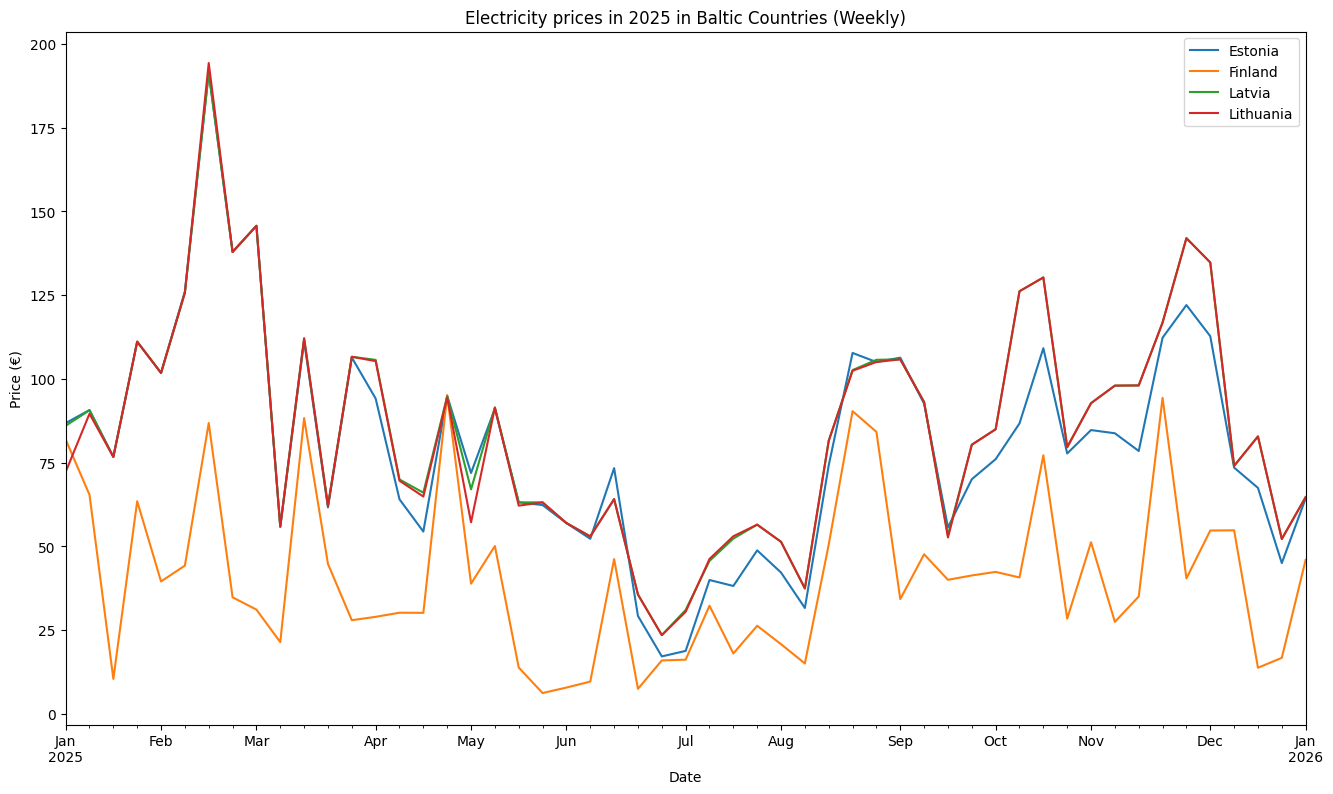

In [110]:
df_prices_weekly = df_prices.resample('W').mean()

df_prices_weekly.rename(columns=name_map).plot(figsize=(16, 9), legend=True, )
plt.title("Electricity prices in 2025 in Baltic Countries (Weekly)")
plt.xlabel("Date")
plt.ylabel("Price (€)");

In [111]:
df_prices

,ee,fi,lv,lt
timestamp,,,,
2024-12-31 23:00:00+00:00,4.8500,4.8500,4.8500,2.9700
2025-01-01 00:00:00+00:00,3.9500,3.9500,3.9500,2.3000
2025-01-01 01:00:00+00:00,3.8000,3.8000,3.8000,2.2800
2025-01-01 02:00:00+00:00,3.4600,3.4600,3.4600,1.8000
2025-01-01 03:00:00+00:00,3.4400,3.4400,3.4400,1.5000
...,...,...,...,...
2025-12-31 18:00:00+00:00,140.1150,140.0000,140.1150,140.1150
2025-12-31 19:00:00+00:00,131.5275,131.4050,131.5275,131.5275
2025-12-31 20:00:00+00:00,130.0400,129.9125,130.0400,130.0400


/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_65090/4259363371.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_prices_monthly = df_prices.resample('M').mean()


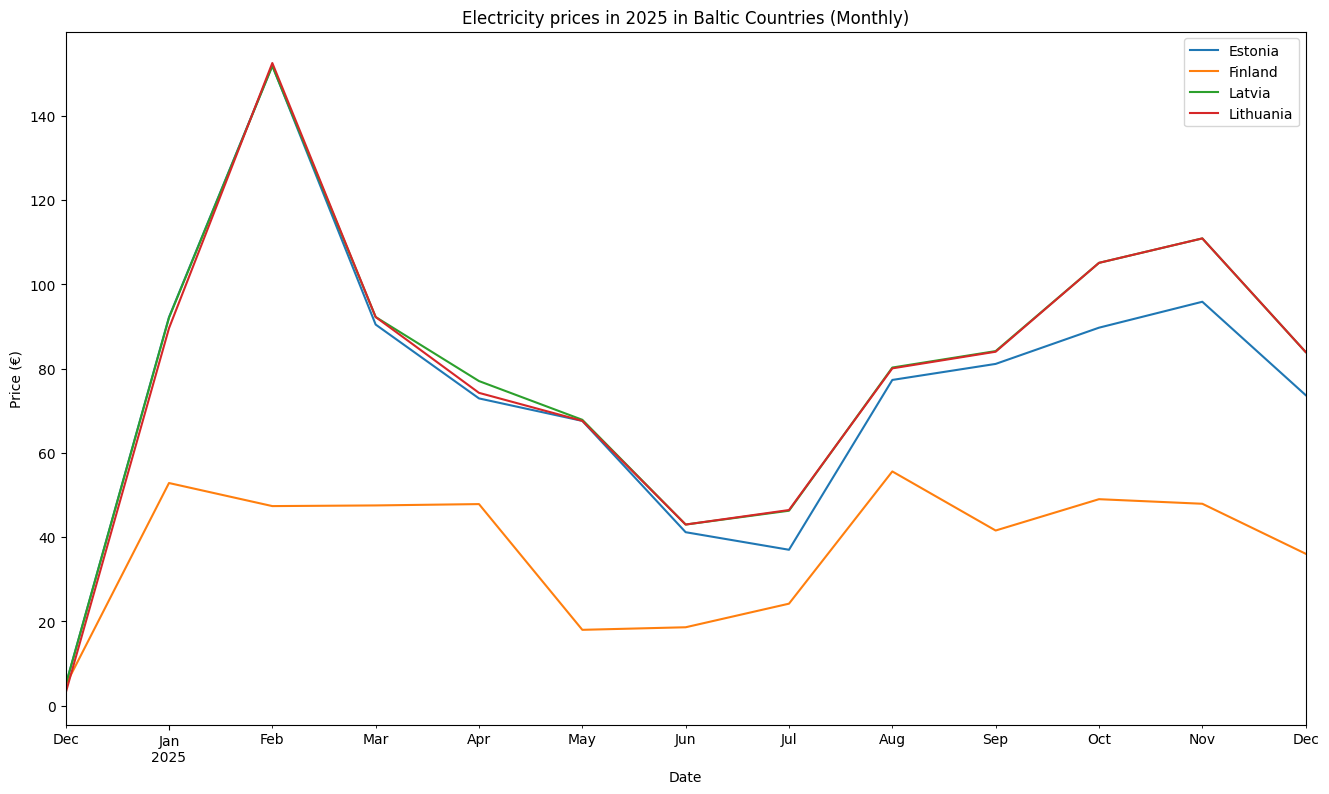

In [112]:
df_prices_monthly = df_prices.resample('M').mean()

df_prices_monthly.rename(columns=name_map).plot(figsize=(16, 9), legend=True, )
plt.title("Electricity prices in 2025 in Baltic Countries (Monthly)")
plt.xlabel("Date")
plt.ylabel("Price (€)");

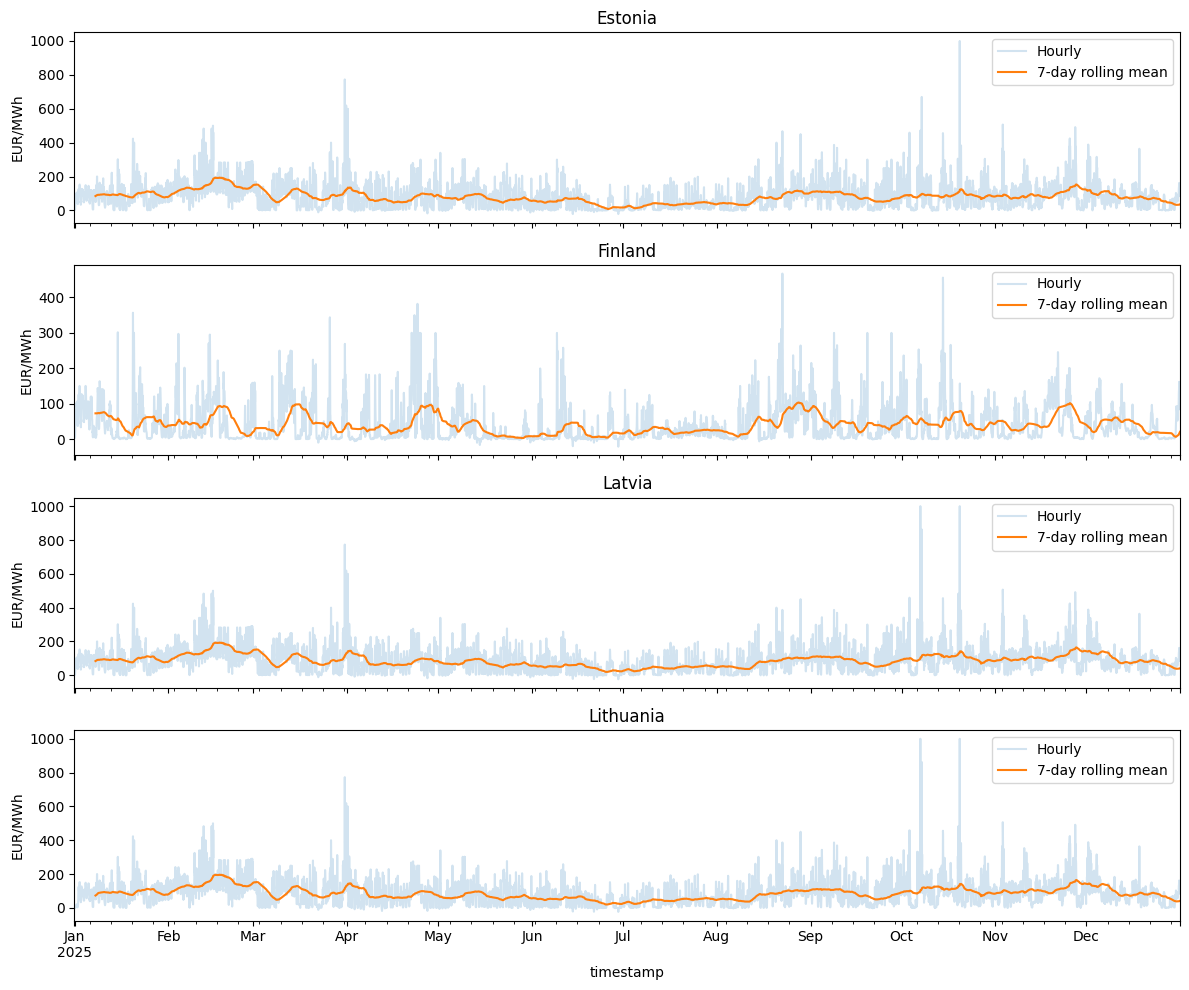

In [113]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
window = 24 * 7

for ax, country in zip(axes, df_prices.columns):
    df_prices[country].plot(ax=ax, alpha=0.2, label='Hourly')
    df_prices[country].rolling(window).mean().plot(ax=ax, label='7-day rolling mean')
    ax.set_title(name_map[country])
    ax.set_ylabel('EUR/MWh')
    ax.legend()

plt.tight_layout()
plt.show()

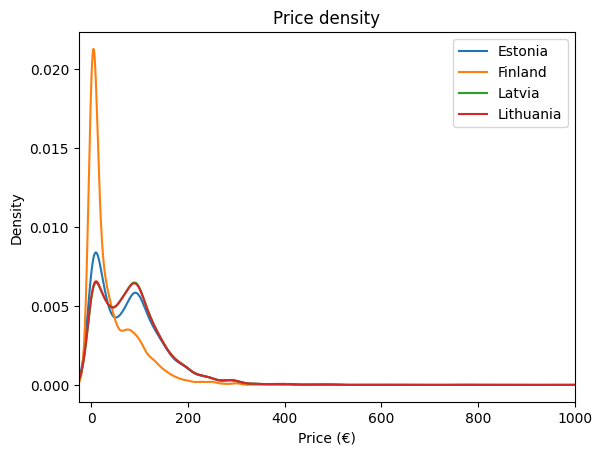

In [114]:
df_prices.rename(columns=name_map).plot.kde()
plt.xlabel("Price (€)")
plt.title("Price density")


ax = plt.gca()
all_min = df_prices.min().min()
all_max = df_prices.max().max()
ax.set_xlim(all_min * 1.1, all_max);

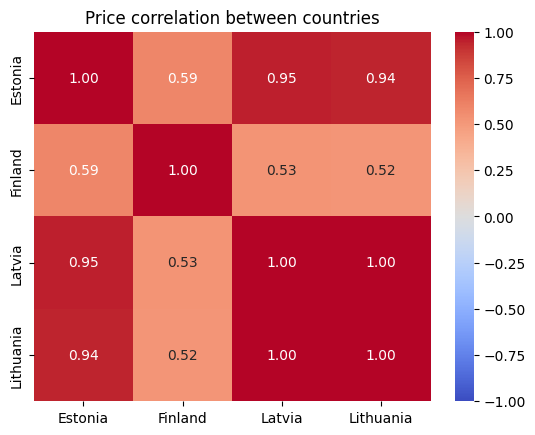

In [115]:
corr = df_prices.rename(columns=name_map).corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Price correlation between countries")
plt.show()

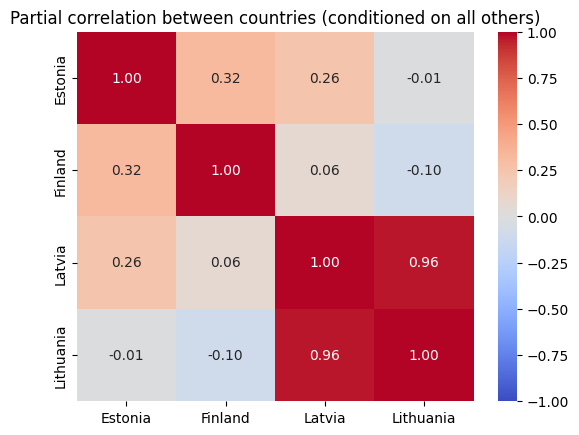

In [116]:
# Generated by AI
def partial_correlation(df: pd.DataFrame) -> pd.DataFrame:
    """Compute partial correlation matrix by inverting the correlation matrix."""
    corr = df.corr()
    inv = pd.DataFrame(np.linalg.inv(corr.values), index=corr.index, columns=corr.columns)
    
    partial_corr = pd.DataFrame(index=corr.index, columns=corr.columns, dtype=float)
    for i in corr.index:
        for j in corr.columns:
            partial_corr.loc[i, j] = -inv.loc[i, j] / np.sqrt(inv.loc[i, i] * inv.loc[j, j])
    
    np.fill_diagonal(partial_corr.values, 1.0)
    return partial_corr

name_map = {'ee': 'Estonia', 'lv': 'Latvia', 'lt': 'Lithuania', 'fi': 'Finland'}
partial_corr = partial_correlation(df_prices.rename(columns=name_map))

sns.heatmap(partial_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Partial correlation between countries (conditioned on all others)")
plt.show()

## Price Prediction in Estonia (only)

I made the choice to predict the daily-price instead hourly. I assume that only now the historic prices of other countries for the prediction.

In [ ]:
target_country = 'ee'
df_prices_daily = df_prices.copy().resample('D').mean()

In [ ]:
def add_shift_features(df: pd.Series, shifts: list[int] = [1]) -> pd.DataFrame:
    target_country = df.name
    X = pd.DataFrame(index=df.index)
    for lag in shifts:
        lag_feature = df.shift(lag)
        X[f'lag_{lag}_{target_country}'] = lag_feature





    return X

def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:

    features = pd.DataFrame(index=df.index)

    day_dummies = pd.get_dummies(df.index.dayofweek, prefix='dow').set_index(df.index)
    features = pd.concat([features, day_dummies], axis=1)

    #features['month']       = df.index.month

    shift_features = pd.concat([
        add_shift_features(df['ee'], shifts=[1, 2, 7, 14]),
        add_shift_features(df['fi'], shifts=[1]),
        add_shift_features(df['lt'], shifts=[1]),
    ], axis=1)

    

    features = pd.concat([features, shift_features], axis=1)

    features = features.iloc[14:] # Drop all NaN values because of the shift features

    return features

In [230]:
X = feature_engineering(df_prices_daily)
feature_names = X.columns.tolist()
X = X.dropna()
index = X.index

X_arr = X.to_numpy()
y = df_prices_daily[target_country].loc[X.index].to_numpy()

split = int(len(X_arr) * 0.75)
X_train, X_test = X_arr[:split], X_arr[split:]
y_train, y_test = y[:split], y[split:]

train_index = index[:split]
test_index  = index[split:]

In [231]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Train:
  MAE:  25.53 EUR/MWh
  RMSE: 33.39 EUR/MWh

Test:
  MAE:  33.76 EUR/MWh
  RMSE: 43.83 EUR/MWh

Coefficients:
  feature  coefficient
    dow_5   -25.167834
    dow_0    22.017434
    dow_2     8.401234
    dow_6    -5.476871
 lag_1_lt     0.327686
 lag_1_ee     0.242190
    dow_4     0.150728
    dow_3     0.149528
 lag_7_ee     0.108014
 lag_1_fi     0.103437
    dow_1    -0.074219
lag_14_ee     0.052181
 lag_2_ee     0.049494


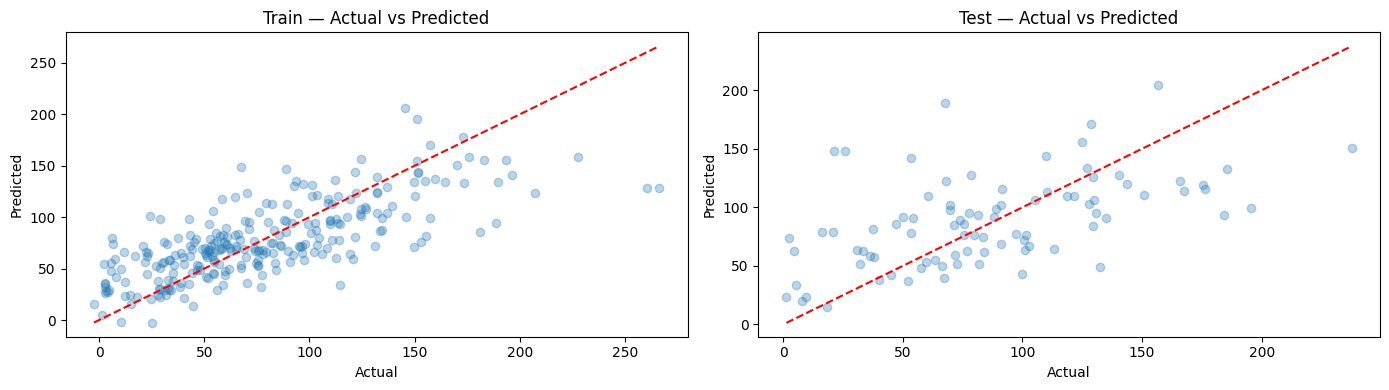

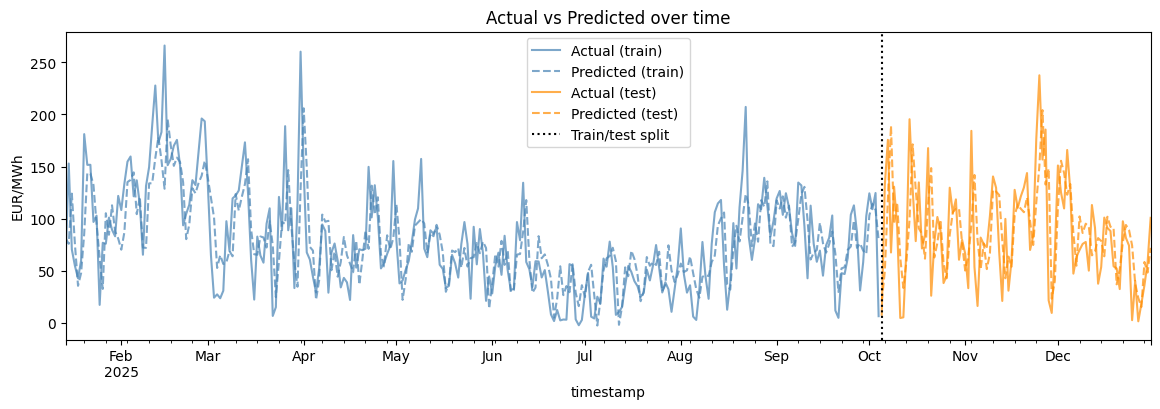

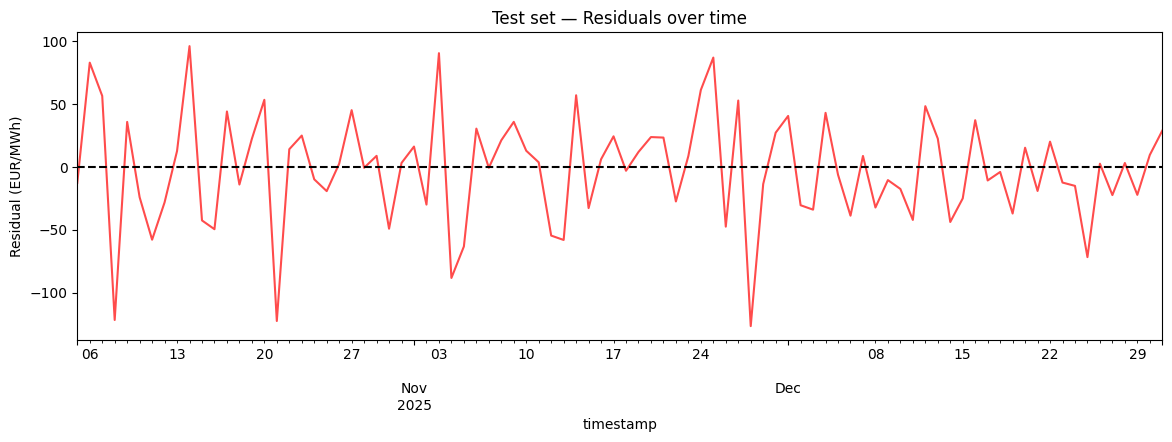

In [232]:
# --- Scores ---
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("Train:")
print(f"  MAE:  {mean_absolute_error(y_train, y_pred_train):.2f} EUR/MWh")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f} EUR/MWh")

print("\nTest:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_test):.2f} EUR/MWh")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f} EUR/MWh")

# --- Coefficients ---
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nCoefficients:")
print(coef_df.to_string(index=False))

# --- Plot: predicted vs actual ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_train, y_pred_train, alpha=0.3)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Train — Actual vs Predicted')

axes[1].scatter(y_test, y_pred_test, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Test — Actual vs Predicted')

plt.tight_layout()
plt.show()

# --- Plot: full time series with train/test split ---
plt.figure(figsize=(14, 4))
pd.Series(y_train, index=train_index).plot(label='Actual (train)', alpha=0.7, color='steelblue')
pd.Series(y_pred_train, index=train_index).plot(label='Predicted (train)', alpha=0.7, color='steelblue', linestyle='--')
pd.Series(y_test, index=test_index).plot(label='Actual (test)', alpha=0.7, color='darkorange')
pd.Series(y_pred_test, index=test_index).plot(label='Predicted (test)', alpha=0.7, color='darkorange', linestyle='--')
plt.axvline(test_index[0], color='black', linestyle=':', label='Train/test split')
plt.ylabel('EUR/MWh')
plt.title('Actual vs Predicted over time')
plt.legend()
plt.show()

# --- Plot: residuals over time ---
plt.figure(figsize=(14, 4))
pd.Series(y_test - y_pred_test, index=test_index).plot(color='red', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Residual (EUR/MWh)')
plt.title('Test set — Residuals over time')
plt.show()